# **04 — Driver Behaviour Scoring**
## **Ma3 | Isolation Forest Anomaly Detection**

Detects dangerous or irregular driver behaviour from trip telemetry
and converts it into a 0–100 daily driver score shown on the
SACCO dashboard and sent to the driver via USSD.

**Why Isolation Forest?**
We don't have labelled "bad driver" data in the real world —
only patterns. Isolation Forest is unsupervised: it learns what
"normal" looks like and flags deviations, without needing labels.
We use the labels in our dataset only for evaluation, not training.

**Features:**
- `speed_variance` — erratic speed changes
- `off_route_ratio` — fraction of trip off designated route
- `avg_dwell_time` — seconds idling at stops
- `harsh_braking_events` — sudden stops per trip
- `trip_duration_min` — total trip time

**Output:**
- `models/score_model.joblib`
- `models/score_scaler.joblib`

In [1]:
import numpy as np
import pandas as pd
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

DATA_DIR  = "../data"
MODEL_DIR = "../models"

print("Libraries loaded ✓")

Libraries loaded ✓


## **Step 1 — Load & Explore**

In [2]:
df = pd.read_csv(f"{DATA_DIR}/driver_dataset.csv")
print(f"Shape: {df.shape}")
print(df.dtypes)
print("\nClass balance:")
print(df["is_anomaly"].value_counts())
print(f"\nAnomaly rate: {df['is_anomaly'].mean():.1%}")
print("\nFeature stats:")
print(df.drop(columns=["driver_id","is_anomaly"]).describe().round(2))

Shape: (3000, 7)
driver_id                object
speed_variance          float64
off_route_ratio         float64
avg_dwell_time          float64
harsh_braking_events      int64
trip_duration_min       float64
is_anomaly                int64
dtype: object

Class balance:
is_anomaly
0    2700
1     300
Name: count, dtype: int64

Anomaly rate: 10.0%

Feature stats:
       speed_variance  off_route_ratio  avg_dwell_time  harsh_braking_events  \
count         3000.00          3000.00         3000.00               3000.00   
mean            15.82             0.08           36.95                  1.87   
std             15.18             0.12           31.49                  2.89   
min              2.01             0.00           10.00                  0.00   
25%              7.54             0.02           20.10                  0.00   
50%             12.36             0.04           29.50                  1.00   
75%             17.13             0.07           39.30                  2.0

## **Step 2 — Visualize Feature Separation**

Before training, confirm that anomalous drivers are actually
separable from normal ones in feature space.
If they overlap completely, no model will work.

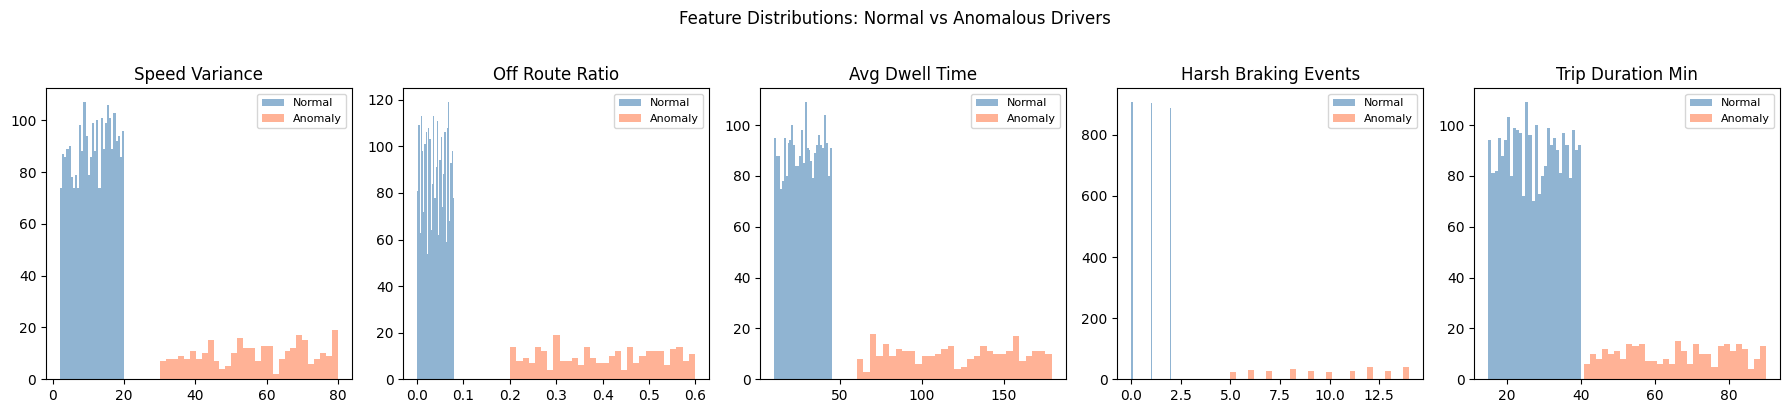

Clear separation visible ✓


In [3]:
FEATURES = [
    "speed_variance", "off_route_ratio",
    "avg_dwell_time", "harsh_braking_events",
    "trip_duration_min"
]

fig, axes = plt.subplots(1, len(FEATURES), figsize=(18, 4))

for i, feat in enumerate(FEATURES):
    normal   = df[df["is_anomaly"] == 0][feat]
    abnormal = df[df["is_anomaly"] == 1][feat]
    axes[i].hist(normal,   bins=30, alpha=0.6, label="Normal",  color="steelblue")
    axes[i].hist(abnormal, bins=30, alpha=0.6, label="Anomaly", color="coral")
    axes[i].set_title(feat.replace("_", " ").title())
    axes[i].legend(fontsize=8)

plt.suptitle("Feature Distributions: Normal vs Anomalous Drivers", y=1.02)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/driver_feature_distributions.png", dpi=100)
plt.show()
print("Clear separation visible ✓")

## **Step 3 — Scale Features**

Isolation Forest is distance-sensitive.
We scale so no single feature dominates by magnitude.
"""

In [4]:
X = df[FEATURES].values
y_true = df["is_anomaly"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

joblib.dump(scaler, f"{MODEL_DIR}/score_scaler.joblib")
print(f"X scaled: {X_scaled.shape}")
print("Scaler saved ✓")

X scaled: (3000, 5)
Scaler saved ✓


## **Step 4 — Train Isolation Forest**

`contamination` = expected fraction of anomalies in real data.
We set 0.10 (10%) matching our dataset's anomaly rate.

Isolation Forest works by randomly partitioning features.
Anomalies are isolated in fewer splits — they get low anomaly scores.
Normal points need many splits to isolate — high anomaly scores.

In [5]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.10,
    max_samples="auto",
    random_state=42,
    n_jobs=-1
)

model.fit(X_scaled)
print("Isolation Forest trained ✓")

# Raw predictions: -1 = anomaly, 1 = normal
raw_preds = model.predict(X_scaled)

# Convert to binary: 1 = anomaly, 0 = normal (match our labels)
y_pred = (raw_preds == -1).astype(int)

print(f"\nFlagged as anomaly: {y_pred.sum()} / {len(y_pred)}")
print(f"Actual anomalies:   {y_true.sum()} / {len(y_true)}")

Isolation Forest trained ✓

Flagged as anomaly: 300 / 3000
Actual anomalies:   300 / 3000


## **Step 5 — Evaluate**

Remember: Isolation Forest is **unsupervised** — it never saw the labels.
We evaluate against labels only to measure real-world accuracy.

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2700
     Anomaly       1.00      1.00      1.00       300

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

ROC-AUC: 1.0000


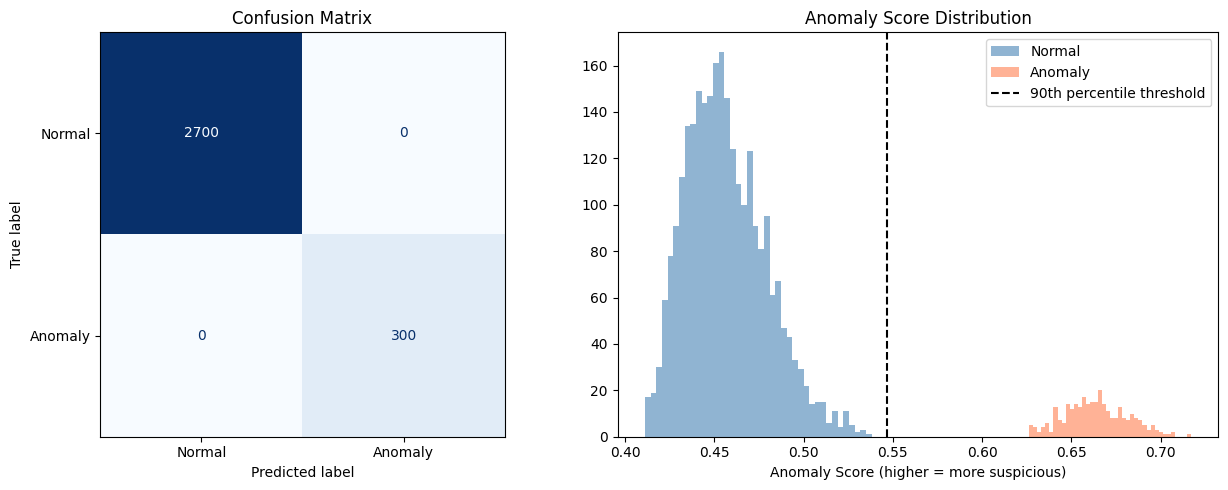

In [6]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Normal", "Anomaly"]))

roc_auc = roc_auc_score(y_true, -model.score_samples(X_scaled))
print(f"ROC-AUC: {roc_auc:.4f}")

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Normal","Anomaly"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Confusion Matrix")

# Anomaly score distribution
scores = -model.score_samples(X_scaled)
axes[1].hist(scores[y_true == 0], bins=40, alpha=0.6, label="Normal",  color="steelblue")
axes[1].hist(scores[y_true == 1], bins=40, alpha=0.6, label="Anomaly", color="coral")
axes[1].axvline(x=np.percentile(scores, 90), color="black",
                linestyle="--", label="90th percentile threshold")
axes[1].set_title("Anomaly Score Distribution")
axes[1].set_xlabel("Anomaly Score (higher = more suspicious)")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/driver_evaluation.png", dpi=100)
plt.show()

## **Step 6 — Driver Score Converter**

Raw anomaly scores → human-readable 0–100 score.

- **80–100** → Safe driver 🟢
- **50–79**  → Monitor 🟡
- **0–49**   → Flag for SACCO review 🔴

This is what drivers see on USSD and SACCOs see on dashboard.

In [8]:
def anomaly_score_to_driver_score(raw_scores):
    """
    raw_scores: output of -model.score_samples(X)
    Higher raw = more anomalous → lower driver score
    """
    # Normalize to 0-1 range
    min_s, max_s = raw_scores.min(), raw_scores.max()
    normalized = (raw_scores - min_s) / (max_s - min_s)
    # Invert: high anomaly score → low driver score
    driver_scores = (1 - normalized) * 100
    return np.clip(driver_scores, 0, 100)

raw_scores   = -model.score_samples(X_scaled)
driver_scores = anomaly_score_to_driver_score(raw_scores)
df["driver_score"] = driver_scores

# Per-driver daily average
driver_summary = (
    df.groupby("driver_id")
    .agg(avg_score=("driver_score", "mean"),
         is_anomaly=("is_anomaly", "first"))
    .sort_values("avg_score", ascending=False)
    .reset_index()
)

print("Driver Leaderboard (Top 20):")
print("=" * 45)
print(f"{'Driver':<12} {'Score':>8} {'Status':>12}")
print("-" * 45)
for _, row in driver_summary.head(20).iterrows():
    status = "🟢 Safe" if row.avg_score >= 80 else \
             "🟡 Monitor" if row.avg_score >= 50 else "🔴 Flagged"
    print(f"{row.driver_id:<12} {row.avg_score:>8.1f} {status:>12}")
print("=" * 45)

Driver Leaderboard (Top 20):
Driver          Score       Status
---------------------------------------------
DRV_006          86.9       🟢 Safe
DRV_002          85.9       🟢 Safe
DRV_016          85.8       🟢 Safe
DRV_004          85.8       🟢 Safe
DRV_013          85.4       🟢 Safe
DRV_015          85.4       🟢 Safe
DRV_008          85.3       🟢 Safe
DRV_018          85.2       🟢 Safe
DRV_019          85.2       🟢 Safe
DRV_007          85.2       🟢 Safe
DRV_014          85.0       🟢 Safe
DRV_005          84.9       🟢 Safe
DRV_003          84.8       🟢 Safe
DRV_010          84.7       🟢 Safe
DRV_017          84.7       🟢 Safe
DRV_009          84.7       🟢 Safe
DRV_011          84.3       🟢 Safe
DRV_012          83.8       🟢 Safe
DRV_001          17.7    🔴 Flagged
DRV_000          17.1    🔴 Flagged


## **Step 7 — Sanity Check**

Simulate scoring a new driver's single trip
as FastAPI would call it at inference time.

In [10]:
def score_driver_trip(speed_variance, off_route_ratio,
                      avg_dwell_time, harsh_braking, duration):
    features = np.array([[speed_variance, off_route_ratio,
                          avg_dwell_time, harsh_braking, duration]])
    scaled = scaler.transform(features)
    raw    = -model.score_samples(scaled)

    # Use training set min/max for normalization
    train_raw = -model.score_samples(X_scaled)
    min_s, max_s = train_raw.min(), train_raw.max()
    normalized = (raw[0] - min_s) / (max_s - min_s)
    score = float(np.clip((1 - normalized) * 100, 0, 100))

    status = "🟢 Safe" if score >= 80 else \
             "🟡 Monitor" if score >= 50 else "🔴 Flagged"
    return round(score, 1), status

print("Live Trip Scoring Simulation:")
print("=" * 55)
trips = [
    ("Normal driver",  5.2,  0.02, 20.0, 1, 25.0),
    ("Slightly risky", 18.0, 0.12, 55.0, 3, 35.0),
    ("Dangerous",      65.0, 0.45, 140.0, 11, 70.0),
]
for label, sv, orr, dt, hb, dur in trips:
    score, status = score_driver_trip(sv, orr, dt, hb, dur)
    print(f"  {label:<18} → Score: {score:>5}/100  {status}")
print("=" * 55)

Live Trip Scoring Simulation:
  Normal driver      → Score:  91.9/100  🟢 Safe
  Slightly risky     → Score:  64.2/100  🟡 Monitor
  Dangerous          → Score:  28.3/100  🔴 Flagged


In [11]:
# Attach min/max to model for consistent inference in FastAPI
model._train_score_min = float((-model.score_samples(X_scaled)).min())
model._train_score_max = float((-model.score_samples(X_scaled)).max())

joblib.dump(model,  f"{MODEL_DIR}/score_model.joblib")
joblib.dump(scaler, f"{MODEL_DIR}/score_scaler.joblib")

print("=" * 45)
print("Model saved  → models/score_model.joblib")
print("Scaler saved → models/score_scaler.joblib")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Drivers scored: {len(driver_summary)}")
print("Ready for 05_save_and_export.ipynb ✓")
print("=" * 45)

Model saved  → models/score_model.joblib
Scaler saved → models/score_scaler.joblib
ROC-AUC: 1.0000
Drivers scored: 20
Ready for 05_save_and_export.ipynb ✓
